In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')

print("✅ All libraries imported!")

✅ All libraries imported!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Praveensai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import pandas as pd
import os

# ✅ 1. Load Twitter Sentiment140
twitter_df = pd.read_csv(
    "taining.160/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    header=None,
    names=['label', 'id', 'date', 'flag', 'user', 'text']
)
twitter_df = twitter_df[['text', 'label']]
twitter_df['label'] = twitter_df['label'].map({0: 'negative', 4: 'positive'})
print("✅ Twitter loaded:", twitter_df.shape)

# ✅ 2. Load IMDb
imdb_df = pd.read_csv("imdb/IMDB Dataset.csv")
imdb_df = imdb_df[['review', 'sentiment']]
imdb_df.columns = ['text', 'label']
print("✅ IMDb loaded:", imdb_df.shape)

# ✅ 3. Load Amazon
amazon_df = pd.read_csv("amazon/train.csv", header=None, names=['label', 'title', 'text'])
amazon_df = amazon_df[['text', 'label']]
amazon_df['label'] = amazon_df['label'].map({1: 'negative', 2: 'positive'})
print("✅ Amazon loaded:", amazon_df.shape)

# ✅ 4. Load Yelp (JSON)
import json

yelp_rows = []
with open("yelp/yelp_academic_dataset_review.json", 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 200000:  # Load only 200k rows to save memory
            break
        row = json.loads(line)
        yelp_rows.append({'text': row['text'], 'stars': row['stars']})

yelp_df = pd.DataFrame(yelp_rows)
yelp_df['label'] = yelp_df['stars'].apply(
    lambda x: 'negative' if x <= 2 else ('neutral' if x == 3 else 'positive')
)
yelp_df = yelp_df[['text', 'label']]
print("✅ Yelp loaded:", yelp_df.shape)

# ✅ 5. Load Google Play
google_df = pd.read_csv("googleplaystore/googleplaystore_user_reviews.csv")
google_df = google_df[['Translated_Review', 'Sentiment']].dropna()
google_df.columns = ['text', 'label']
google_df['label'] = google_df['label'].str.lower()
print("✅ Google Play loaded:", google_df.shape)

✅ Twitter loaded: (1600000, 2)
✅ IMDb loaded: (50000, 2)
✅ Amazon loaded: (3600000, 2)
✅ Yelp loaded: (200000, 2)
✅ Google Play loaded: (37427, 2)


In [4]:
# Merge
df = pd.concat([twitter_df, imdb_df, amazon_df, yelp_df, google_df], ignore_index=True)

# Drop missing values
df = df.dropna(subset=['text', 'label'])

print("✅ Total combined shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())

✅ Total combined shape: (5487427, 2)

Label distribution:
label
positive    2788312
negative    2671309
neutral       27806
Name: count, dtype: int64


✅ Balanced shape: (600000, 2)
label
positive    200000
negative    200000
neutral     200000
Name: count, dtype: int64


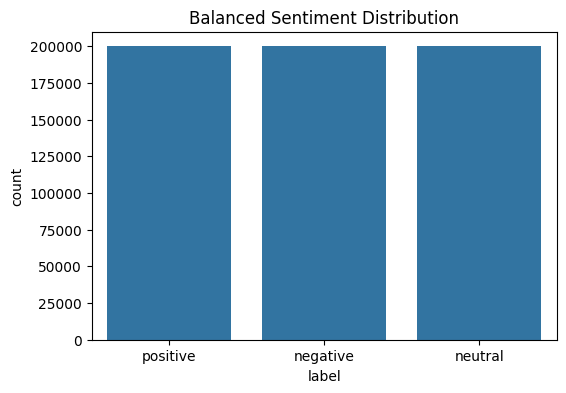

In [5]:
positive_df = df[df['label'] == 'positive']
negative_df = df[df['label'] == 'negative']
neutral_df  = df[df['label'] == 'neutral']

positive_df = positive_df.sample(n=200000, random_state=42)
negative_df = negative_df.sample(n=200000, random_state=42)
neutral_df  = neutral_df.sample(n=200000, random_state=42, replace=True)

df_balanced = pd.concat([positive_df, negative_df, neutral_df], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Balanced shape:", df_balanced.shape)
print(df_balanced['label'].value_counts())

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_balanced)
plt.title("Balanced Sentiment Distribution")
plt.show()

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

# ✅ Remove negation words from stopwords
stop_words = set(stopwords.words('english'))

negation_words = {
    'not', 'no', 'nor',
    "don't", "doesn't", "didn't",
    "won't", "can't", "isn't",
    "aren't", "wasn't", "weren't",
    'never', 'neither', 'nobody',
    'nothing', 'nowhere', 'hardly',
    'barely', 'scarcely'
}

stop_words = stop_words - negation_words
print("✅ Negation words preserved:", negation_words)

stemmer = PorterStemmer()

emoji_map = {
    "😍": " love ", "❤️": " love ", "😊": " happy ",
    "😂": " laugh ", "😢": " sad ", "😡": " angry ",
    "👍": " good ", "👎": " bad "
}

# ✅ Updated clean function
def clean_text_v2(text):
    text = str(text).lower()
    for emoji, meaning in emoji_map.items():
        text = text.replace(emoji, meaning)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [stemmer.stem(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

# ✅ Apply new cleaning
print("⏳ Cleaning with negation preserved... (3-4 mins)")
df_balanced['cleaned_v2'] = df_balanced['text'].apply(clean_text_v2)
print("✅ Done!")

# ✅ Quick check
examples = [
    "Not bad at all!",
    "I don't hate it but I don't love it",
    "I can't believe how good this is!",
    "Never disappointed with this product",
]
print("\n📋 Negation Preservation Check:")
print("-" * 50)
for ex in examples:
    print(f"Original : {ex}")
    print(f"Cleaned  : {clean_text_v2(ex)}")
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Praveensai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Negation words preserved: {"didn't", "can't", 'never', "won't", 'scarcely', 'nothing', "aren't", "isn't", "don't", 'nor', "weren't", 'no', 'nowhere', "wasn't", 'neither', 'barely', 'hardly', 'nobody', "doesn't", 'not'}
⏳ Cleaning with negation preserved... (3-4 mins)
✅ Done!

📋 Negation Preservation Check:
--------------------------------------------------
Original : Not bad at all!
Cleaned  : not bad

Original : I don't hate it but I don't love it
Cleaned  : hate love

Original : I can't believe how good this is!
Cleaned  : believ good

Original : Never disappointed with this product
Cleaned  : never disappoint product



In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Save cleaned dataset
df_balanced.to_csv("cleaned_sentiment_dataset.csv", index=False)
print("✅ Cleaned dataset saved!")

# Encode labels
df_balanced['label_encoded'] = df_balanced['label'].map({
    'positive': 2, 'neutral': 1, 'negative': 0
})

# ✅ Split
X = df_balanced['cleaned_v2']
y = df_balanced['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ TF-IDF
print("⏳ Vectorizing...")
tfidf_v2 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)
X_train_vec = tfidf_v2.fit_transform(X_train)
X_test_vec  = tfidf_v2.transform(X_test)
print("✅ Vectorization done!")

# ✅ Retrain SVM
print("⏳ Retraining SVM...")
svm_v2 = LinearSVC(random_state=42, max_iter=1000)
svm_v2.fit(X_train_vec, y_train)

train_acc = round(accuracy_score(y_train, svm_v2.predict(X_train_vec)) * 100, 2)
test_acc  = round(accuracy_score(y_test, svm_v2.predict(X_test_vec)) * 100, 2)

print("\n✅ Retrained SVM Results")
print("─" * 40)
print(f"Training Accuracy : {train_acc}%")
print(f"Testing Accuracy  : {test_acc}%")
print("─" * 40)
print(classification_report(y_test, svm_v2.predict(X_test_vec),
      target_names=['negative', 'neutral', 'positive']))

✅ Cleaned dataset saved!
⏳ Vectorizing...
✅ Vectorization done!
⏳ Retraining SVM...

✅ Retrained SVM Results
────────────────────────────────────────
Training Accuracy : 90.28%
Testing Accuracy  : 86.45%
────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83     40000
     neutral       0.93      0.97      0.95     40000
    positive       0.82      0.81      0.81     40000

    accuracy                           0.86    120000
   macro avg       0.86      0.86      0.86    120000
weighted avg       0.86      0.86      0.86    120000



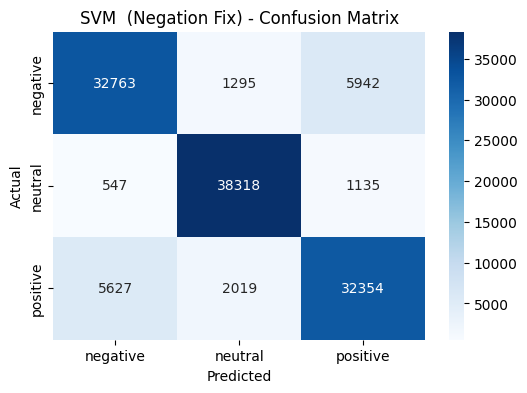

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_v2_test_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("SVM  (Negation Fix) - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

⏳ Training Logistic Regression with negation fix... (3-5 mins)

✅ Logistic Regression v2 Results
────────────────────────────────────────
Old Training Accuracy : 87.80%
New Training Accuracy : 88.47%
────────────────────────────────────────
Old Testing Accuracy  : 85.39%
New Testing Accuracy  : 86.2%
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.82      0.83     40000
     neutral       0.92      0.96      0.94     40000
    positive       0.82      0.81      0.81     40000

    accuracy                           0.86    120000
   macro avg       0.86      0.86      0.86    120000
weighted avg       0.86      0.86      0.86    120000



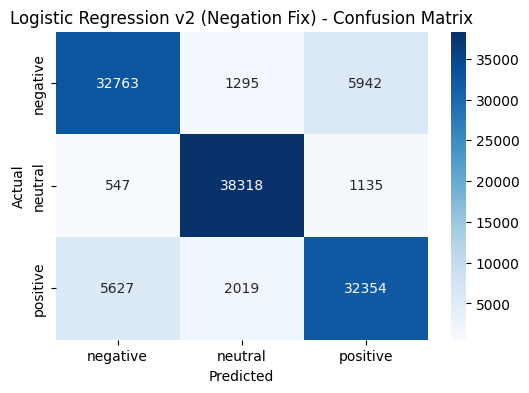

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("⏳ Training Logistic Regression with negation fix... (3-5 mins)")
lr_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_v2.fit(X_train_vec, y_train)

lr_v2_train_pred = lr_v2.predict(X_train_vec)
lr_v2_test_pred  = lr_v2.predict(X_test_vec)

print("\n✅ Logistic Regression v2 Results")
print("─" * 40)
print(f"Old Training Accuracy : 87.80%")
print(f"New Training Accuracy : {round(accuracy_score(y_train, lr_v2_train_pred)*100,2)}%")
print("─" * 40)
print(f"Old Testing Accuracy  : 85.39%")
print(f"New Testing Accuracy  : {round(accuracy_score(y_test, lr_v2_test_pred)*100,2)}%")
print("─" * 40)
print("\nClassification Report:")
print(classification_report(y_test, lr_v2_test_pred, target_names=['negative','neutral','positive']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_v2_test_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Logistic Regression v2 (Negation Fix) - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

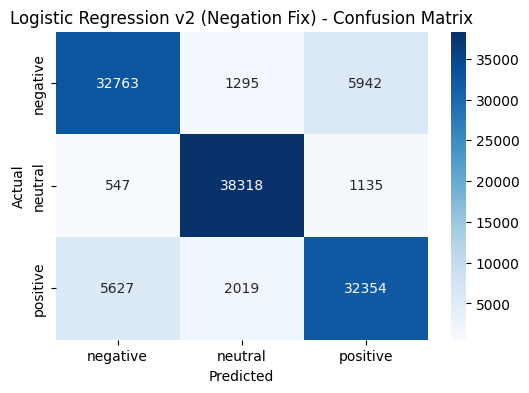

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_v2_test_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Logistic Regression v2 (Negation Fix) - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

⏳ Training Naive Bayes with negation fix... (fast!)

✅ Naive Bayes v2 Results
────────────────────────────────────────
Old Training Accuracy : 80.64%
New Training Accuracy : 81.16%
────────────────────────────────────────
Old Testing Accuracy  : 79.48%
New Testing Accuracy  : 80.05%
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.80      0.77     40000
     neutral       0.88      0.86      0.87     40000
    positive       0.78      0.74      0.76     40000

    accuracy                           0.80    120000
   macro avg       0.80      0.80      0.80    120000
weighted avg       0.80      0.80      0.80    120000



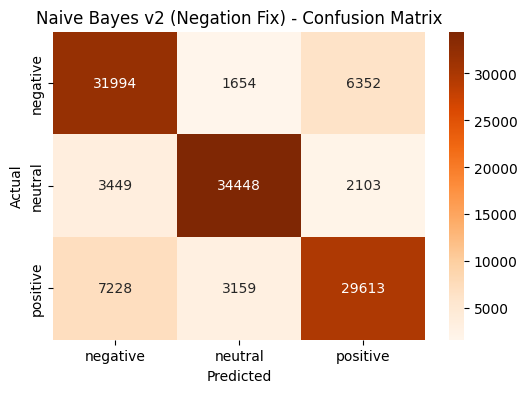

In [12]:
from sklearn.naive_bayes import MultinomialNB

print("⏳ Training Naive Bayes with negation fix... (fast!)")
nb_v2 = MultinomialNB()
nb_v2.fit(X_train_vec, y_train)

nb_v2_train_pred = nb_v2.predict(X_train_vec)
nb_v2_test_pred  = nb_v2.predict(X_test_vec)

print("\n✅ Naive Bayes v2 Results")
print("─" * 40)
print(f"Old Training Accuracy : 80.64%")
print(f"New Training Accuracy : {round(accuracy_score(y_train, nb_v2_train_pred)*100,2)}%")
print("─" * 40)
print(f"Old Testing Accuracy  : 79.48%")
print(f"New Testing Accuracy  : {round(accuracy_score(y_test, nb_v2_test_pred)*100,2)}%")
print("─" * 40)
print("\nClassification Report:")
print(classification_report(y_test, nb_v2_test_pred, target_names=['negative','neutral','positive']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_v2_test_pred),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Naive Bayes v2 (Negation Fix) - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

⏳ Training SVM... (5-10 mins)

✅ SVM Results
────────────────────────────────────────
Training Accuracy : 90.28%
Testing Accuracy  : 86.45%
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83     40000
     neutral       0.93      0.97      0.95     40000
    positive       0.82      0.81      0.81     40000

    accuracy                           0.86    120000
   macro avg       0.86      0.86      0.86    120000
weighted avg       0.86      0.86      0.86    120000



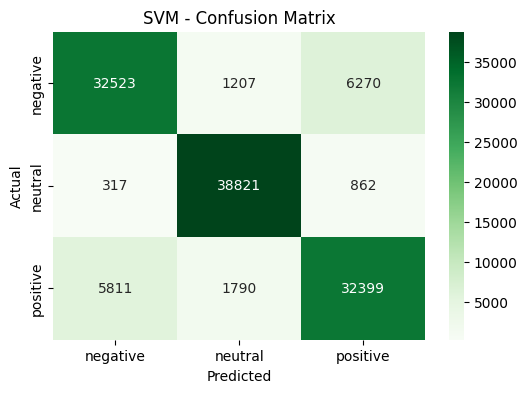

In [13]:
from sklearn.svm import LinearSVC

print("⏳ Training SVM... (5-10 mins)")

svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train_vec, y_train)

svm_train_pred = svm_model.predict(X_train_vec)
svm_test_pred  = svm_model.predict(X_test_vec)

print("\n✅ SVM Results")
print("─" * 40)
print(f"Training Accuracy : {round(accuracy_score(y_train, svm_train_pred) * 100, 2)}%")
print(f"Testing Accuracy  : {round(accuracy_score(y_test, svm_test_pred) * 100, 2)}%")
print("─" * 40)
print("\nClassification Report:")
print(classification_report(y_test, svm_test_pred, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_test_pred),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("SVM - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

                 Model  Training Accuracy  Testing Accuracy
0  Logistic Regression              88.47             86.20
1          Naive Bayes              81.16             80.05
2                  SVM              90.28             86.45


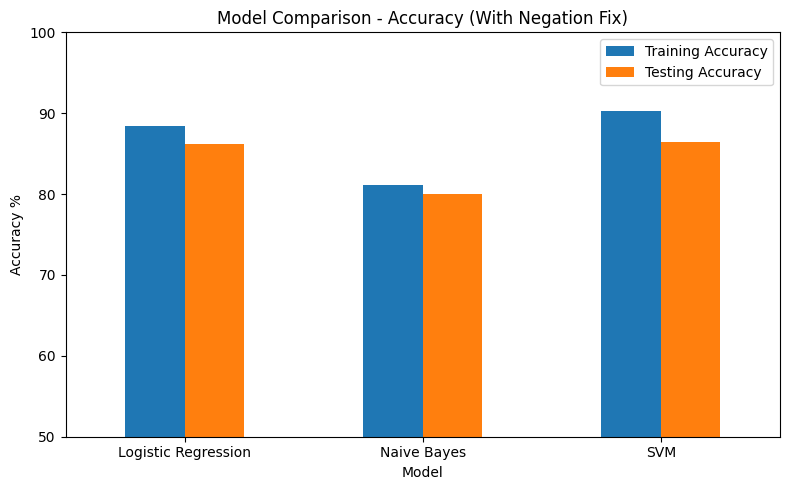

In [14]:
results = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Training Accuracy': [
        round(accuracy_score(y_train, lr_v2_train_pred) * 100, 2),
        round(accuracy_score(y_train, nb_v2_train_pred) * 100, 2),
        round(accuracy_score(y_train, svm_v2.predict(X_train_vec)) * 100, 2)
    ],
    'Testing Accuracy': [
        round(accuracy_score(y_test, lr_v2_test_pred) * 100, 2),
        round(accuracy_score(y_test, nb_v2_test_pred) * 100, 2),
        round(accuracy_score(y_test, svm_v2_test_pred) * 100, 2)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.plot(x='Model', kind='bar', figsize=(8,5), rot=0)
plt.title("Model Comparison - Accuracy (With Negation Fix)")
plt.ylabel("Accuracy %")
plt.ylim(50, 100)
plt.tight_layout()
plt.show()

In [18]:
import pickle

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(svm_v2, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_v2, f)

print("✅ Model saved as sentiment_model.pkl")
print("✅ Vectorizer saved as tfidf_vectorizer.pkl")

✅ Model saved as sentiment_model.pkl
✅ Vectorizer saved as tfidf_vectorizer.pkl


In [19]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(random_state=42, max_iter=1000)
calibrated_svm = CalibratedClassifierCV(base_svm, cv=3)
calibrated_svm.fit(X_train_vec, y_train)

# Test
test_acc = accuracy_score(y_test, calibrated_svm.predict(X_test_vec))
print("Testing Accuracy:", round(test_acc*100, 2), "%")

# Save this instead
import pickle
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(calibrated_svm, f)

Testing Accuracy: 86.55 %


In [20]:
import pickle
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(calibrated_svm, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_v2, f)

print("✅ Calibrated model saved!")

✅ Calibrated model saved!


In [21]:
import pandas as pd

sample_data = {
    'text': [
        "This product is absolutely amazing, best purchase ever!",
        "The service was terrible and I will never come back.",
        "It was okay, nothing special about it.",
        "Not bad at all, pretty decent for the price.",
        "I don't hate it but I don't love it either.",
        "Worst app I have ever used, keeps crashing.",
        "Great quality and fast delivery, highly recommend!",
        "Average experience, could be better.",
        "Absolutely loved the food and ambiance!",
        "Waste of money, do not buy this."
    ]
}

sample_df = pd.DataFrame(sample_data)
sample_df.to_csv("sample_reviews.csv", index=False)
print("✅ sample_reviews.csv created!")

✅ sample_reviews.csv created!
